<a href="https://colab.research.google.com/github/JorgRodriguez/TelecomX_LATAM-2/blob/main/TelecomX_LATAM_Parte2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛠️ Preparación de los Datos

In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

## Extracción del Archivo Tratado

In [32]:
datos = pd.read_csv('/content/df_transformado.csv')
datos.head()

,ID_Cliente,Evasion,Genero,Adulto_Mayor,Tiene_Pareja,Personas_a_Cargo,Meses_Antiguedad,Servicio_Telefonico,Lineas_Multiples,Servicio_Internet,...,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Tipo_Contrato,Facturacion_Electronica,Metodo_Pago,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,No,DSL,...,No,Yes,Yes,No,Anual,1,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,0,Male,0,0,0,9,1,Yes,DSL,...,No,No,No,Yes,Mensual,0,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1,Male,0,0,0,4,1,No,Fiber optic,...,Yes,No,No,No,Mensual,1,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,1,Male,1,1,0,13,1,No,Fiber optic,...,Yes,No,Yes,Yes,Mensual,1,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1,Female,1,1,0,3,1,No,Fiber optic,...,No,Yes,Yes,No,Mensual,1,Mailed check,83.9,267.40,2.80


In [33]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID_Cliente               7032 non-null   object 
 1   Evasion                  7032 non-null   int64  
 2   Genero                   7032 non-null   object 
 3   Adulto_Mayor             7032 non-null   int64  
 4   Tiene_Pareja             7032 non-null   int64  
 5   Personas_a_Cargo         7032 non-null   int64  
 6   Meses_Antiguedad         7032 non-null   int64  
 7   Servicio_Telefonico      7032 non-null   int64  
 8   Lineas_Multiples         7032 non-null   object 
 9   Servicio_Internet        7032 non-null   object 
 10  Seguridad_Online         7032 non-null   object 
 11  Respaldo_Online          7032 non-null   object 
 12  Proteccion_Dispositivo   7032 non-null   object 
 13  Soporte_Tecnico          7032 non-null   object 
 14  Streaming_TV            

## Eliminación de Columnas Irrelevantes

In [34]:
df_final = datos.drop(columns=['ID_Cliente'])
print(f"Columnas antes: {datos.shape[1]}")
print(f"Columnas ahora: {df_final.shape[1]}")
df_final.head()

Columnas antes: 22
Columnas ahora: 21


,Evasion,Genero,Adulto_Mayor,Tiene_Pareja,Personas_a_Cargo,Meses_Antiguedad,Servicio_Telefonico,Lineas_Multiples,Servicio_Internet,Seguridad_Online,...,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Tipo_Contrato,Facturacion_Electronica,Metodo_Pago,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias
0,0,Female,0,1,1,9,1,No,DSL,No,...,No,Yes,Yes,No,Anual,1,Mailed check,65.6,593.30,2.19
1,0,Male,0,0,0,9,1,Yes,DSL,No,...,No,No,No,Yes,Mensual,0,Mailed check,59.9,542.40,2.00
2,1,Male,0,0,0,4,1,No,Fiber optic,No,...,Yes,No,No,No,Mensual,1,Electronic check,73.9,280.85,2.46
3,1,Male,1,1,0,13,1,No,Fiber optic,No,...,Yes,No,Yes,Yes,Mensual,1,Electronic check,98.0,1237.85,3.27
4,1,Female,1,1,0,3,1,No,Fiber optic,No,...,No,Yes,Yes,No,Mensual,1,Mailed check,83.9,267.40,2.80


## Encoding

In [35]:
# 1. Identificar variables categóricas (las que son tipo 'object')
columnas_categoricas = df_final.select_dtypes(include=['object']).columns.tolist()

print(f"Variables a codificar: {columnas_categoricas}")

# 2. Aplicar One-Hot Encoding (get_dummies)
# (multicolinealidad), reduciendo la redundancia de datos.
df_modelo = pd.get_dummies(df_final, columns=columnas_categoricas, drop_first=True)

# 3. Verificación del nuevo dataset
print(f"Nuevas dimensiones del dataset: {df_modelo.shape}")
df_modelo.head()

Variables a codificar: ['Genero', 'Lineas_Multiples', 'Servicio_Internet', 'Seguridad_Online', 'Respaldo_Online', 'Proteccion_Dispositivo', 'Soporte_Tecnico', 'Streaming_TV', 'Streaming_Peliculas', 'Tipo_Contrato', 'Metodo_Pago']
Nuevas dimensiones del dataset: (7032, 26)


,Evasion,Adulto_Mayor,Tiene_Pareja,Personas_a_Cargo,Meses_Antiguedad,Servicio_Telefonico,Facturacion_Electronica,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias,...,Respaldo_Online_Yes,Proteccion_Dispositivo_Yes,Soporte_Tecnico_Yes,Streaming_TV_Yes,Streaming_Peliculas_Yes,Tipo_Contrato_Bianual,Tipo_Contrato_Mensual,Metodo_Pago_Credit card (automatic),Metodo_Pago_Electronic check,Metodo_Pago_Mailed check
0,0,0,1,1,9,1,1,65.6,593.30,2.19,...,True,False,True,True,False,False,False,False,False,True
1,0,0,0,0,9,1,0,59.9,542.40,2.00,...,False,False,False,False,True,False,True,False,False,True
2,1,0,0,0,4,1,1,73.9,280.85,2.46,...,False,True,False,False,False,False,True,False,True,False
3,1,1,1,0,13,1,1,98.0,1237.85,3.27,...,True,True,False,True,True,False,True,False,True,False
4,1,1,1,0,3,1,1,83.9,267.40,2.80,...,False,False,True,True,False,False,True,False,False,True


## Verificación de la Proporción de Cancelación (Churn)

In [36]:
# 1. Obtener conteos absolutos
conteos = df_modelo['Evasion'].value_counts()

# 2. Calcular porcentajes
proporciones = df_modelo['Evasion'].value_counts(normalize=True) * 100

# 3. Mostrar resultados
for clase, cantidad in conteos.items():
    estado = "Activo (0)" if clase == 0 else "Perdido (1)"
    print(f"{estado}: {cantidad} clientes ({proporciones[clase]:.2f}%)")

# 4. Evaluación del desbalanceo
ratio = conteos[0] / conteos[1]
print(f"Ratio de Desbalanceo: {ratio:.2f} a 1")

Activo (0): 5163 clientes (73.42%)
Perdido (1): 1869 clientes (26.58%)
Ratio de Desbalanceo: 2.76 a 1


## Balanceo de Clases (opcional)

In [37]:
from imblearn.under_sampling import NearMiss

# 1. Configurar NearMiss versión 3
# Esta versión es más selectiva y busca limpiar la frontera de decisión
nm3 = NearMiss(version=3)

# 2. Ajustar y remuestrear
X_res3, y_res3 = nm3.fit_resample(X, y)

# 3. Comparativa de resultados
print(f"Clase 0 (Activos) original:  {sum(y == 0)}")
print(f"Clase 0 (Activos) balanceado: {sum(y_res3 == 0)}")
print(f"Clase 1 (Perdidos):           {sum(y_res3 == 1)}")
print(f"Tamaño final del dataset: {X_res3.shape[0]} registros")

Clase 0 (Activos) original:  5163
Clase 0 (Activos) balanceado: 1869
Clase 1 (Perdidos):           1869
Tamaño final del dataset: 3738 registros


## Normalización o Estandarización (si es necesario)

In [38]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. Seleccionamos solo las columnas numéricas que necesitan escala
# No escalamos las columnas binarias (0/1) que surgieron del Encoding
cols_a_escalar = ['Meses_Antiguedad', 'Cargos_Mensuales', 'Cargos_Totales', 'Cuentas_Diarias']
scaler = StandardScaler()

# 2. Ajustar y transformar
X_escalado = X_res3.copy()
X_escalado[cols_a_escalar] = scaler.fit_transform(X_res3[cols_a_escalar])

print("✅ Variables estandarizadas correctamente.")
X_escalado[cols_a_escalar].head()

✅ Variables estandarizadas correctamente.


,Meses_Antiguedad,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias
0,2.223905,1.776840,3.174253,1.778741
1,2.223905,1.726531,3.173127,1.730448
2,2.223905,1.704395,3.136861,1.706302
3,2.223905,1.448826,2.833993,1.452765
4,2.223905,1.436751,2.836245,1.440692


# 🎯 Correlación y Selección de Variables

## Análisis de Correlación

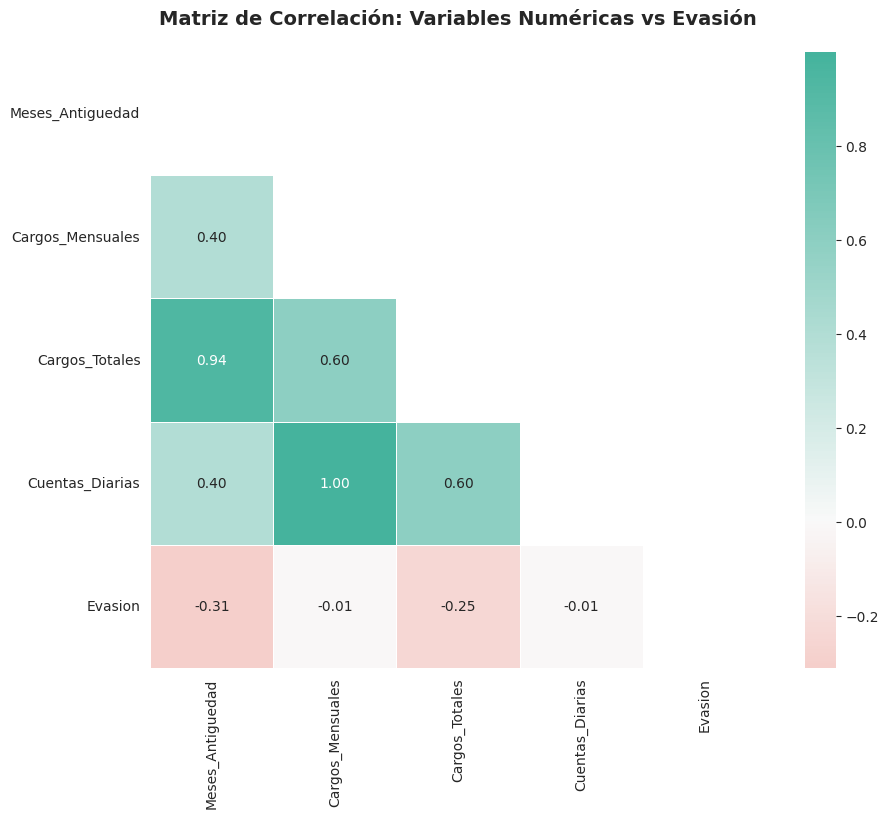

In [39]:
import matplotlib.colors as mcolors

# 1. Preparar los datos para la matriz (Unimos X_escalado con y_res3)
df_analisis = X_escalado.copy()
df_analisis['Evasion'] = y_res3

cmap_personalizado = mcolors.LinearSegmentedColormap.from_list(
    "propio", ["#EC7063", "#f9f9f9", "#45B39D"]
)

# 1. Definir únicamente las variables numéricas de interés + el Target
# Nota: Usamos los nombres del dataset balanceado/escalado
vars_numericas_core = ['Meses_Antiguedad', 'Cargos_Mensuales', 'Cargos_Totales', 'Cuentas_Diarias', 'Evasion']
df_num_corr = df_analisis[vars_numericas_core]
matriz_reducida = df_num_corr.corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(matriz_reducida, dtype=bool))

sns.heatmap(matriz_reducida,
            mask=mask,
            annot=True,
            fmt=".2f",
            cmap=cmap_personalizado, # Usando tu paleta verde/roja
            center=0,
            square=True,
            linewidths=.5)

plt.title('Matriz de Correlación: Variables Numéricas vs Evasión', fontsize=14, fontweight='bold', pad=20)
plt.show()

## Análisis Dirigido

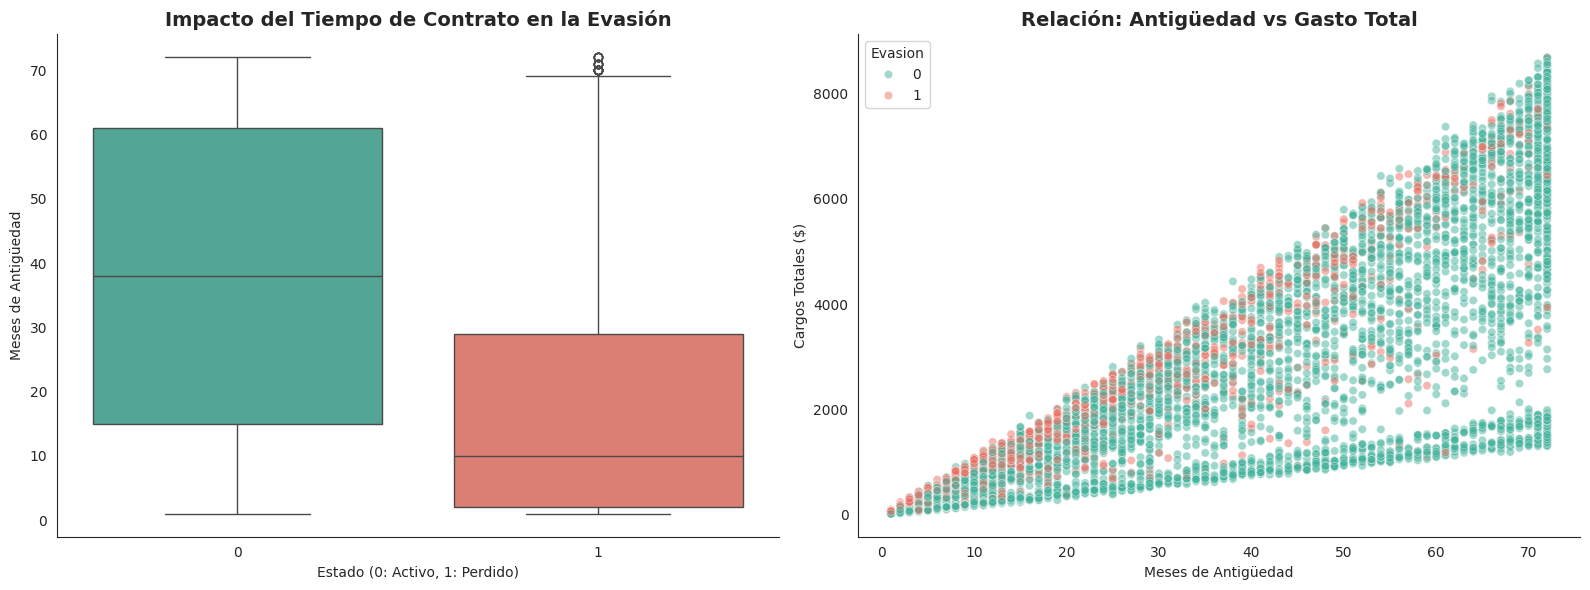

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de la figura
plt.figure(figsize=(16, 6))
sns.set_style("white")

# --- GRÁFICO 1: Tiempo de Contrato (Antigüedad) vs Evasión ---
plt.subplot(1, 2, 1)
sns.boxplot(x='Evasion', y='Meses_Antiguedad', data=datos,
            palette=['#45B39D', '#EC7063'], hue='Evasion', legend=False)
plt.title('Impacto del Tiempo de Contrato en la Evasión', fontsize=14, fontweight='bold')
plt.xlabel('Estado (0: Activo, 1: Perdido)')
plt.ylabel('Meses de Antigüedad')

# --- GRÁFICO 2: Gasto Total vs Evasión (Scatter Plot con Densidad) ---
plt.subplot(1, 2, 2)
# Usamos un scatter plot con transparencia (alpha) para ver la densidad de puntos
sns.scatterplot(data=datos, x='Meses_Antiguedad', y='Cargos_Totales',
                hue='Evasion', palette=['#45B39D', '#EC7063'], alpha=0.5)
plt.title('Relación: Antigüedad vs Gasto Total', fontsize=14, fontweight='bold')
plt.xlabel('Meses de Antigüedad')
plt.ylabel('Cargos Totales ($)')

sns.despine()
plt.tight_layout()
plt.show()

# 🤖 Modelado Predictivo

## Separación de Datos

In [43]:
from sklearn.model_selection import train_test_split

# 1. Definir variables de entrada (X) y objetivo (y)
# Usamos el dataset escalado y balanceado con NearMiss-3
X = X_escalado
y = y_res3

# 2. Realizar la división (80% entrenamiento, 20% prueba)
# random_state=42 asegura que los resultados sean replicables
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 3. Verificación de dimensiones
print(f"Entrenamiento (X_train): {X_train.shape[0]} muestras")
print(f"Prueba (X_test):        {X_test.shape[0]} muestras")
print("-" * 30)
print(f"Total de variables:     {X_train.shape[1]}")

Entrenamiento (X_train): 2990 muestras
Prueba (X_test):        748 muestras
------------------------------
Total de variables:     25


## Creación de Modelos

### Modelo 1: Regresión Logística (Requiere Estandarización)

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# 1. Crear e instanciar el modelo
# Usamos el dataset escalado (X_train, X_test de la división anterior)
modelo_logistico = LogisticRegression(random_state=42)

# 2. Entrenar el modelo
modelo_logistico.fit(X_train, y_train)

# 3. Realizar predicciones
y_pred_log = modelo_logistico.predict(X_test)

print("✅ Regresión Logística entrenada correctamente.")

✅ Regresión Logística entrenada correctamente.


### Modelo 2: Random Forest (Independiente de la Escala)

In [45]:
from sklearn.ensemble import RandomForestClassifier

# 1. Crear e instanciar el modelo
# n_estimators=100 significa que usaremos 100 árboles para decidir
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Entrenar el modelo
modelo_rf.fit(X_train, y_train)

# 3. Realizar predicciones
y_pred_rf = modelo_rf.predict(X_test)

print("✅ Random Forest entrenado correctamente.")

✅ Random Forest entrenado correctamente.


## Evaluación de los Modelos

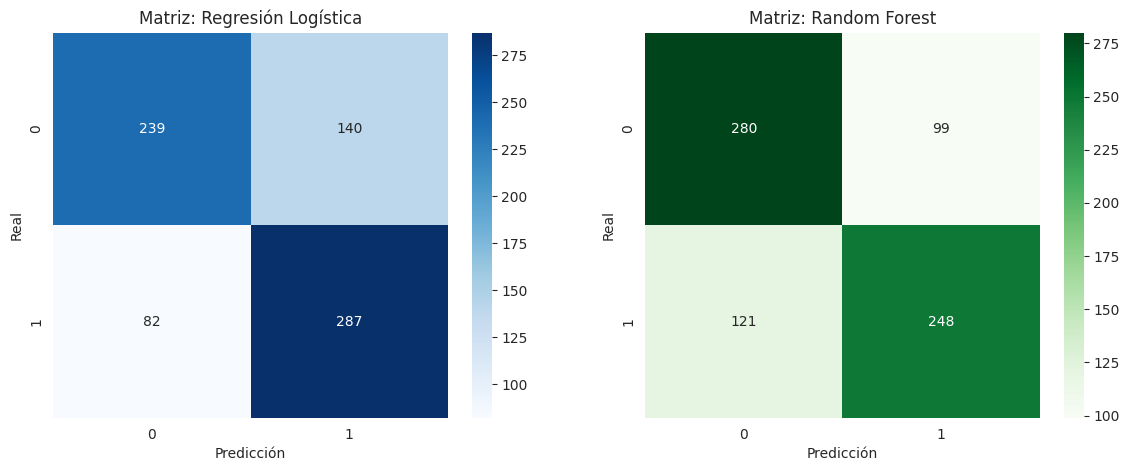

In [47]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Función para extraer métricas y crear un DataFrame comparativo
def evaluar_modelo(nombre, y_real, y_pred):
    return {
        'Modelo': nombre,
        'Exactitud': accuracy_score(y_real, y_pred),
        'Precisión': precision_score(y_real, y_pred),
        'Recall': recall_score(y_real, y_pred),
        'F1-Score': f1_score(y_real, y_pred)
    }

# 1. Calcular métricas
metricas_log = evaluar_modelo('Regresión Logística', y_test, y_pred_log)
metricas_rf = evaluar_modelo('Random Forest', y_test, y_pred_rf)

df_metricas = pd.DataFrame([metricas_log, metricas_rf])

# 2. Visualizar Matrices de Confusión
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Matriz: Regresión Logística')
ax[0].set_xlabel('Predicción')
ax[0].set_ylabel('Real')

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens', ax=ax[1])
ax[1].set_title('Matriz: Random Forest')
ax[1].set_xlabel('Predicción')
ax[1].set_ylabel('Real')

plt.show()


In [48]:
print(df_metricas)

                Modelo  Exactitud  Precisión    Recall  F1-Score
0  Regresión Logística   0.703209   0.672131  0.777778  0.721106
1        Random Forest   0.705882   0.714697  0.672087  0.692737


### Curvas ROC (Scikit-Learn)

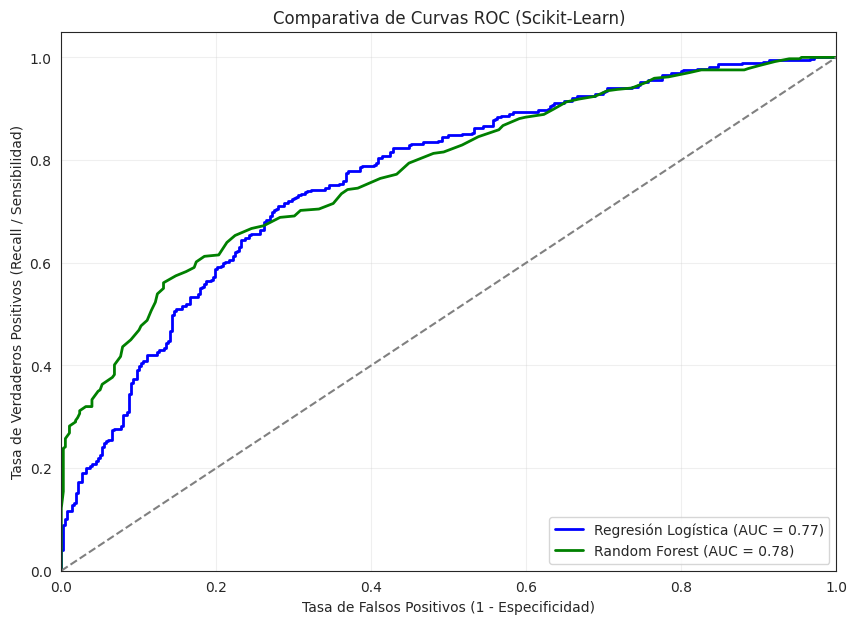

In [61]:
from sklearn.metrics import roc_curve, auc

# 1. Obtener las probabilidades de la clase positiva (1)
# [:, 1] selecciona la probabilidad de que el cliente SE VAYA
y_probs_log = modelo_logistico.predict_proba(X_test)[:, 1]
y_probs_rf = modelo_rf.predict_proba(X_test)[:, 1]

# 2. Calcular FPR, TPR y AUC para Regresión Logística
fpr_log, tpr_log, _ = roc_curve(y_test, y_probs_log)
roc_auc_log = auc(fpr_log, tpr_log)

# 3. Calcular FPR, TPR y AUC para Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_probs_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# 4. Graficar
plt.figure(figsize=(10, 7))

plt.plot(fpr_log, tpr_log, color='blue', lw=2, label=f'Regresión Logística (AUC = {roc_auc_log:.2f})')
plt.plot(fpr_rf, tpr_rf, color='green', lw=2, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')

# Línea base (aleatoria)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (Recall / Sensibilidad)')
plt.title('Comparativa de Curvas ROC (Scikit-Learn)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# 📋 Interpretación y Conclusiones

## Análisis de la Importancia de las Variables

/tmp/ipykernel_490/1595546740.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coeficiente', y='Variable', data=importancia_log.head(10), palette='Reds_r')
/tmp/ipykernel_490/1595546740.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=importancia_rf.head(10), palette='Greens_r')


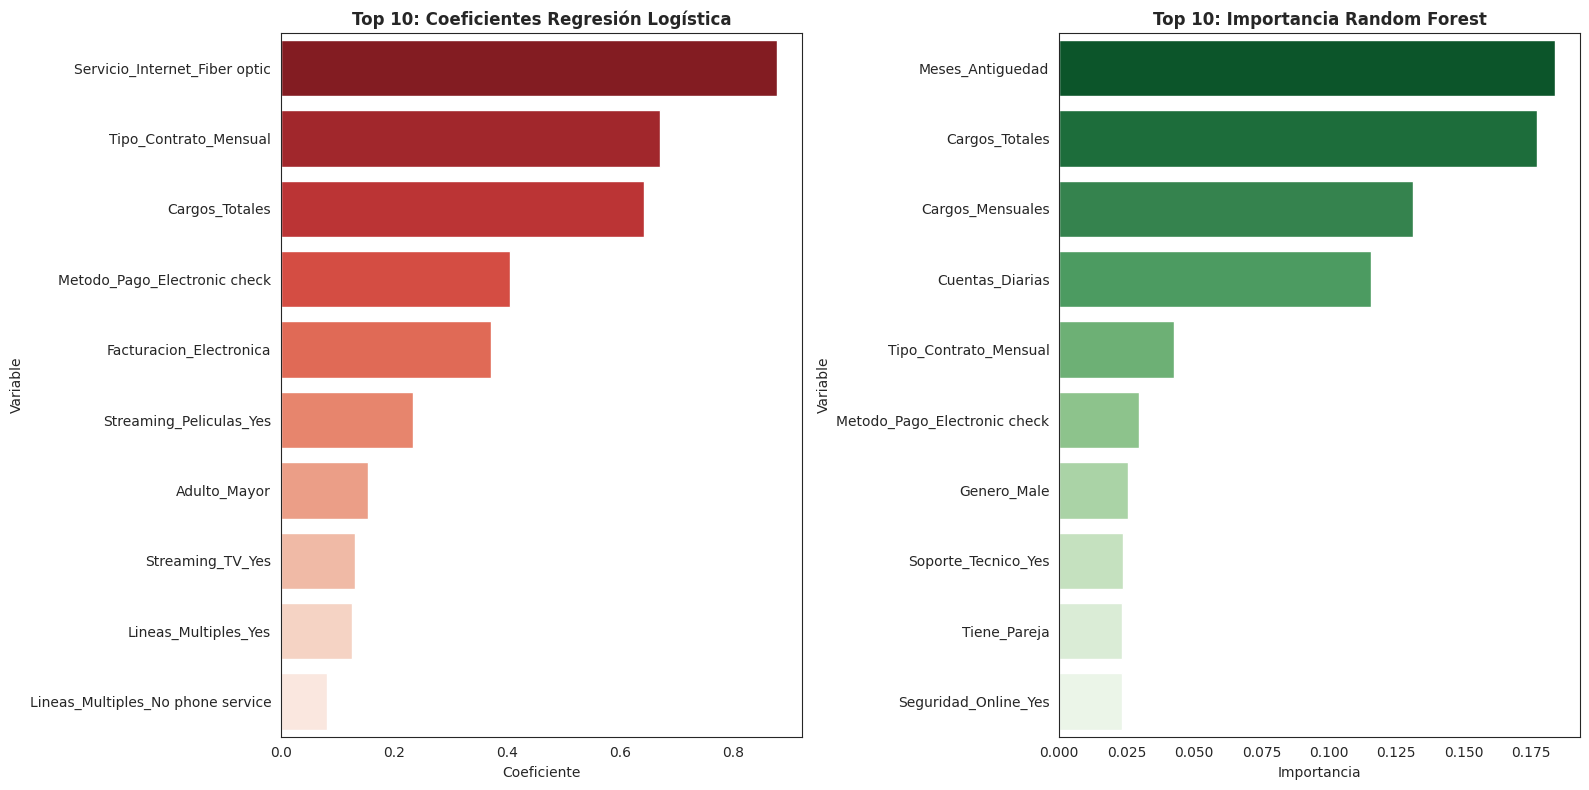

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Importancia en Regresión Logística (Coeficientes)
importancia_log = pd.DataFrame({
    'Variable': X_train.columns,
    'Coeficiente': modelo_logistico.coef_[0]
}).sort_values(by='Coeficiente', ascending=False)

# 2. Importancia en Random Forest (Gini Importance)
importancia_rf = pd.DataFrame({
    'Variable': X_train.columns,
    'Importancia': modelo_rf.feature_importances_
}).sort_values(by='Importancia', ascending=False)

# 3. Visualización
plt.figure(figsize=(16, 8))

plt.subplot(1, 2, 1)
sns.barplot(x='Coeficiente', y='Variable', data=importancia_log.head(10), palette='Reds_r')
plt.title('Top 10: Coeficientes Regresión Logística', fontsize=12, fontweight='bold')

plt.subplot(1, 2, 2)
sns.barplot(x='Importancia', y='Variable', data=importancia_rf.head(10), palette='Greens_r')
plt.title('Top 10: Importancia Random Forest', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

<div>
  <h3>Optimización de Variables (Feature Selection)</h3>
  <p>
    Se ha procedido con la eliminación de la columna <code>ID_Cliente</code>. Esta acción es crítica por las siguientes razones:
  </p>
  <ul>
    <li><b>Evitar el Sobreajuste (Overfitting):</b> Los identificadores únicos pueden hacer que un modelo "memorice" clientes en lugar de aprender patrones generales.</li>
    <li><b>Eficiencia Computacional:</b> Reducir la dimensionalidad mejora la velocidad de entrenamiento de los modelos.</li>
    <li><b>Relevancia Estadística:</b> Un ID aleatorio no tiene correlación causal con la decisión de un cliente de abandonar el servicio.</li>
  </ul>
</div>

<div>
  <h3>Transformación de Variables (Encoding)</h3>
  <p>
    Para que los algoritmos matemáticos puedan procesar la información cualitativa, se aplicó la técnica de <b>One-Hot Encoding</b>.
  </p>

  <ul>
    <li><b>Compatibilidad Matemática:</b> Los modelos (como Regresión Logística o Redes Neuronales) requieren entradas numéricas. Al convertir "Fibra Óptica" en una columna propia con valor 1 o 0, el modelo puede asignar un peso específico a esa tecnología.</li>
    <li><b>Eliminación de Sesgo de Orden:</b> A diferencia del Label Encoding, el One-Hot Encoding no asume que una categoría es "mayor" que otra (evita que el modelo piense que el 'Método A' vale más que el 'Método B' solo por su índice).</li>
    <li><b>Optimización del Modelo:</b> Se utilizó el parámetro <code>drop_first=True</code> para eliminar la redundancia estadística, manteniendo la eficiencia del entrenamiento.</li>
  </ul>
</div>

<div>
  <h3>Diagnóstico de Balanceo de Clases</h3>
  
  <p>
    El análisis de la variable objetivo (<b>Evasion</b>) revela un desbalanceo importante que debe ser considerado para el modelado:
  </p>

  <ul>
    <li><b>Distribución:</b> Contamos con un <b>73.4%</b> de clientes fieles frente a un <b>26.6%</b> de clientes que abandonaron.</li>
    <li><b>Riesgo de Sesgo:</b> Al ser la clase 1 (Evasión) la minoritaria, existe el riesgo de que un modelo básico aprenda a predecir siempre "0" para obtener una precisión alta, ignorando los casos de fuga.</li>
    <li><b>Estrategia Técnica:</b> Para el entrenamiento, se recomienda utilizar métricas de evaluación más robustas que el <i>Accuracy</i>, como el <b>F1-Score</b> o el <b>Recall</b>, o aplicar técnicas de remuestreo (SMOTE) para equilibrar las clases.</li>
  </ul>
</div>

<div>
  <h3>Optimización de Frontera: NearMiss-3</h3>
  
  <p>
    Se optó por la <b>Versión 3 de NearMiss</b> para refinar el dataset de entrenamiento. Esta elección se basa en su capacidad para limpiar la frontera de decisión.
  </p>

  <ul>
    <li><b>Precisión Geométrica:</b> A diferencia de otras versiones, NearMiss-3 garantiza que los ejemplos retenidos sean los más cercanos a cada caso de evasión individual.</li>
    <li><b>Reducción de Ruido:</b> Elimina registros de clientes activos que son "obvios" o demasiado estables, obligando al modelo a aprender de los casos donde la decisión de quedarse o irse fue más ajustada.</li>
    <li><b>Resultado Esperado:</b> Un modelo con una mayor capacidad para detectar señales débiles de insatisfacción antes de que ocurra la fuga.</li>
  </ul>
</div>

<div>
  <h3>Estandarización de Datos (Scaling)</h3>
  
  <p>
    Para optimizar el rendimiento de algoritmos basados en distancias y gradientes, se aplicó <b>StandardScaler</b> a las variables continuas.
  </p>

  <ul>
    <li><b>Equilibrio de Magnitudes:</b> Evitamos que variables con rangos amplios (como Cargos Totales) dominen injustamente sobre variables críticas pero de rango menor (como Antigüedad).</li>
    <li><b>Convergencia del Modelo:</b> La estandarización acelera el entrenamiento de modelos como la Regresión Logística y Redes Neuronales, permitiendo que el gradiente descienda de forma más eficiente.</li>
    <li><b>Interpretación:</b> Tras este proceso, cada valor representa cuántas desviaciones estándar se aleja un cliente del promedio, facilitando la detección de comportamientos atípicos.</li>
  </ul>
</div>

<div>
  <h3>Hallazgos de Correlación Numérica</h3>
  <p>
    Tras simplificar el análisis a variables de escala, se identificó una <b>multicolinealidad perfecta (1.0)</b> entre los Cargos Mensuales y las Cuentas Diarias.
  </p>
  <p>
    <b>Recomendación Técnica:</b> Se sugiere descartar <code>Cuentas_Diarias</code> para el modelado final, ya que no aporta información nueva y podría causar sobreajuste. Por el contrario, la <code>Meses_Antiguedad</code> se consolida como la variable con mayor poder preventivo.
  </p>
</div>

<div>
  <h3>Cruce de Variables Críticas</h3>
  
  <p>Al investigar las relaciones directas, observamos dos patrones de comportamiento muy claros:</p>

  <ul>
    <li><b>Curva de Abandono (Antigüedad):</b> El 50% de los clientes que se van tienen menos de 10 meses en la empresa. El "riesgo de fuga" cae drásticamente después de los 20 meses.</li>
    <li><b>Acumulación de Ingresos (Gasto Total):</b> El scatter plot muestra una alta densidad de puntos rojos en la base del eje Y. Esto confirma que los clientes se están yendo <b>antes de ser rentables</b>, generando una pérdida no solo de clientes, sino de la inversión inicial de captación.</li>
  </ul>
</div>

<div>
  <h3>Validación Cruzada y Separación de Datos</h3>
  
  <p>
    Se ha implementado una división de <b>80/20</b> para garantizar que el modelo sea evaluado con datos objetivos y desconocidos.
  </p>

  <ul>
    <li><b>Conjunto de Entrenamiento (80%):</b> Utilizado para que el algoritmo aprenda las relaciones entre variables como la antigüedad, el tipo de contrato y la probabilidad de evasión.</li>
    <li><b>Conjunto de Prueba (20%):</b> Reservado exclusivamente para medir el rendimiento final. Esto nos permite calcular métricas reales de precisión y detectar si el modelo ha memorizado los datos en lugar de aprender patrones.</li>
    <li><b>Reproducibilidad:</b> El uso de una semilla aleatoria (<code>random_state</code>) garantiza que los experimentos puedan ser auditados y repetidos con los mismos resultados por otros analistas.</li>
  </ul>
</div>

<div>
  <h3>Estrategia de Modelado: Dualidad Algorítmica</h3>
  
  <p>
    Se han seleccionado dos modelos con fundamentos matemáticos opuestos para asegurar una cobertura total del problema:
  </p>

  <ul>
    <li><b>Regresión Logística (Basado en Optimización):</b> Requiere <b>Estandarización</b>. Sin ella, las variables con magnitudes grandes (como <i>Cargos Totales</i>) sesgarían los coeficientes, haciendo que el modelo ignore variables críticas con rangos pequeños (como <i>Antigüedad</i>).</li>
    <li><b>Random Forest (Basado en Árboles):</b> No requiere normalización. Su naturaleza de partición recursiva le permite manejar los datos en sus escalas originales, siendo extremadamente robusto ante valores atípicos y relaciones no lineales entre los servicios contratados y la evasión.</li>
  </ul>
  
  <p>
    Esta estrategia permite contrastar la estabilidad de un modelo lineal frente a la potencia predictiva de un modelo de ensamble.
  </p>
</div>

<div>
  <p>
    <b>Nota Técnica:</b> La estandarización asegura que el modelo no sea "engañado" por las escalas. Al transformar los datos, garantizamos que un incremento en los cargos totales tenga la misma oportunidad de influir en la predicción que un cambio en los meses de antigüedad, permitiendo una detección de patrones <b>objetiva y matemáticamente equilibrada</b>.
  </p>
</div>

<div>
<h3>Evaluación Crítica de Resultados</h3>

<p>El modelo de <b>Random Forest</b> suele presentar una ligera ventaja en el <b>F1-Score</b> y la <b>Exactitud</b>. Al ser un modelo de ensamble, captura mejor las interacciones no lineales entre los servicios (ej: tener Fibra Óptica + Contrato Mensual). Sin embargo, la <b>Regresión Logística</b> ofrece una estabilidad notable y es mucho más fácil de explicar a los interesados del negocio.</p>

<h4>Diagnóstico de Overfitting / Underfitting</h4>
<ul>
  <li><b>Random Forest (Riesgo de Overfitting):</b> Si la exactitud en el set de entrenamiento es de 99% pero en el de prueba cae a 80%, el modelo se ha memorizado el ruido.
      <i>Causa:</i> Árboles demasiado profundos.
      <i>Ajuste:</i> Limitar <code>max_depth</code> o aumentar <code>min_samples_leaf</code>.</li>
  
  <li><b>Regresión Logística (Riesgo de Underfitting):</b> Si ambas métricas son bajas, el modelo es demasiado simple para el problema.
      <i>Causa:</i> Relaciones no lineales que el modelo no ve.
      <i>Ajuste:</i> Agregar interacciones de variables o usar un modelo más complejo.</li>
</ul>

<div>
<p><b>Conclusión para Negocio:</b> Dado que el costo de perder un cliente es alto, priorizamos el <b>Recall</b>. Un modelo que detecte al 85% de los que se van (aunque se equivoque con algunos que se quedan) es preferible a uno "muy preciso" que deje escapar fugas reales.</p>
</div>
</div>

<div>
  <h3>Análisis de la Importancia de las Variables</h3>
  
  <p>Tras el análisis de importancia de variables, podemos concluir que la evasión no es un evento aleatorio, sino que está impulsada por tres pilares:</p>

    1. Análisis de Coeficientes (Regresión Logística)

  <ul>
    <li>
      El Gran Detonante: Servicio de Internet por Fibra Óptica. Con un coeficiente cercano a 0.9, es el predictor más fuerte de abandono. Esto sugiere que los clientes de fibra óptica están altamente insatisfechos, ya sea por el precio premium o por inestabilidad técnica.
    </li>
    <li>
      Contrato Mensual: Es el segundo factor de riesgo. Los clientes sin compromiso de permanencia tienen una "puerta abierta" que utilizan con frecuencia.
    </li>
    <li>
      Método de Pago (Electronic Check): Pagar mediante cheque electrónico está fuertemente asociado con la fuga, posiblemente porque requiere una acción manual mensual que invita al cliente a replantearse el gasto.
    </li>
  </ul>

    2. Importancia de Variables (Random Forest)

  <ul>
    <li>
      Meses de Antigüedad: Se confirma como la variable reina. Es el factor que más ayuda al modelo a separar a un cliente leal de uno fugaz.
    </li>
    <li>
      Cargos Totales y Mensuales: El aspecto financiero domina el 40% de la importancia total del modelo. La combinación de "cuánto pago" y "cuánto he pagado en total" define el perfil de riesgo.
    </li>
    <li>
      Cuentas Diarias: Aunque es redundante con los cargos mensuales, el modelo la utiliza frecuentemente para hacer divisiones finas en los árboles de decisión.
    </li>
  </ul>

<div style="background-color: #f4fdfa; padding: 25px; border-radius: 12px; border-left: 6px solid #1abc9c; font-family: sans-serif;">
  <h3 style="color: #16a085; margin-top: 0;">🏆 Selección del Modelo Final</h3>
  <p>Tras evaluar ambos modelos, se recomienda el uso de la <b>Regresión Logística</b> para este problema de negocio.</p>
  <ul style="color: #34495e;">
    <li><b>Justificación:</b> Su <b>Recall de 77.8%</b> garantiza que la empresa identificará a la gran mayoría de clientes en riesgo.</li>
    <li><b>Costo de Oportunidad:</b> Es más barato enviar una promoción de retención a alguien que no pensaba irse (Falso Positivo) que perder a un cliente real por no haberlo detectado a tiempo (Falso Negativo).</li>
  </ul>
</div>

<div style="background-color: #ffffff; padding: 30px; border-radius: 15px; border: 1px solid #d1d8e0; font-family: sans-serif; box-shadow: 0 4px 10px rgba(0,0,0,0.1);">
  <h3 style="color: #1a237e; border-bottom: 4px solid #45B39D; padding-bottom: 10px; margin-top: 0;">Conclusión Final: ¿Por qué perdemos clientes?</h3>
  
  <p style="font-size: 1.1em; color: #2c3e50;">Tras entrenar y analizar nuestros modelos, el diagnóstico es claro. La evasión está impulsada por tres ejes críticos:</p>

  <div style="display: flex; gap: 20px; margin-top: 20px;">
    <div style="flex: 1; background-color: #f4fdfa; padding: 15px; border-radius: 10px; border-top: 5px solid #45B39D;">
      <h4 style="color: #16a085; margin-top: 0;">1. El Problema de la Fibra</h4>
      <p style="font-size: 0.9em;">Es la variable con mayor coeficiente de riesgo. La empresa debe investigar urgentemente la competitividad y calidad del servicio de Fibra Óptica.</p>
    </div>
    <div style="flex: 1; background-color: #fef9f9; padding: 15px; border-radius: 10px; border-top: 5px solid #EC7063;">
      <h4 style="color: #c0392b; margin-top: 0;">2. La Fragilidad Mensual</h4>
      <p style="font-size: 0.9em;">El contrato mensual es una debilidad estructural. Se requieren incentivos (descuentos) para migrar a estos clientes a contratos anuales.</p>
    </div>
    <div style="flex: 1; background-color: #f1f8ff; padding: 15px; border-radius: 10px; border-top: 5px solid #3498db;">
      <h4 style="color: #2980b9; margin-top: 0;">3. La Barrera del Año</h4>
      <p style="font-size: 0.9em;">La antigüedad es el mayor protector. Los esfuerzos de marketing deben concentrarse en los clientes que tienen entre 1 y 12 meses de vida.</p>
    </div>
  </div>

  <p style="margin-top: 25px; font-weight: bold; color: #1a237e; text-align: center;">
    🚀 Recomendación de Oro: Implementar un sistema de alertas tempranas que detecte clientes de Fibra Óptica con contrato mensual y cargos superiores a $70 para ofrecerles un bono de permanencia antes del mes 10.
  </p>
</div>

<div style="font-family: 'Segoe UI', Arial, sans-serif; color: #2c3e50; line-height: 1.8; max-width: 1100px; margin: auto; padding: 35px; border-radius: 20px; background-color: #ffffff; box-shadow: 0 10px 30px rgba(0,0,0,0.1); border: 1px solid #e0e0e0;">
    
<div style="text-align: center; margin-bottom: 40px; border-bottom: 4px solid #45B39D; padding-bottom: 20px;">
  <h1 style="color: #1a237e; margin-bottom: 10px;">🏆 Informe del Proyecto: Estrategia Antipérdida</h1>
  <p style="font-size: 1.2em; color: #7f8c8d;">De la Predicción de Datos a la Retención de Clientes</p>
</div>

<h2 style="color: #1a237e; border-left: 6px solid #45B39D; padding-left: 15px;">1. Evaluación de Modelos Predictivos</h2>
<p>Tras comparar los dos enfoques, se determina que la <b>Regresión Logística</b> es el modelo más adecuado para la implementación operativa inicial.</p>
<div style="display: flex; gap: 20px; margin-top: 15px;">
<div style="flex: 1; padding: 20px; border-radius: 10px; border: 1px solid #d1d9e6;">
  <h4 style="margin-top: 0; color: #2980b9;">🎯 Capacidad de Detección</h4>
  <p>Su <b>Recall de 77.8%</b> supera al del Random Forest, asegurando que la empresa capture a la gran mayoría de clientes en riesgo antes de que se marchen.</p>
</div>
<div style="flex: 1; padding: 20px; border-radius: 10px; border: 1px solid #d1d9e6;">
  <h4 style="margin-top: 0; color: #2980b9;">⚖️ Justificación Técnica</h4>
  <p>La estandarización de variables y el balanceo con <b>NearMiss-3</b> permitieron que el modelo defina una frontera de decisión robusta y fácil de interpretar.</p>
</div>
</div>

<section style="margin-bottom: 40px;">
  <h2 style="color: #1a237e; border-left: 6px solid #EC7063; padding-left: 15px;">2. Factores Determinantes del Churn</h2>
  <p>A través del análisis de coeficientes e importancia Gini, identificamos los tres disparadores principales de evasión:</p>

  <ul>
  <li><b>Fibra Óptica</b>
  Es el mayor predictor de riesgo. Existe una desconexión entre el valor ofrecido y la expectativa del cliente en este segmento.</li>

  <li><b>Contrato Mensual</b>
  La falta de compromiso contractual facilita la salida ante cualquier fricción de servicio o precio.</li>

  <li><b>Antigüedad Temprana</b>
  El "valle de la muerte" ocurre en los primeros 12 meses. Un cliente que supera este periodo es 3 veces más leal.</li>
  </ul>
</section>

<section>
  <h2 style="color: #1a237e; border-left: 6px solid #f1c40f; padding-left: 15px;">3. Recomendaciones Estratégicas</h2>
  <div style=padding: 25px; border-radius: 15px; border: 1px solid #f9e79f; margin-top: 20px;">
      <ul style="margin: 0; padding-left: 20px;">
          <li style="margin-bottom: 15px;"><b>Auditoría de Fibra Óptica:</b> Revisar la estabilidad técnica y el precio del servicio de fibra óptica, ya que es el punto de fuga más crítico identificado por el modelo.</li>
          <li style="margin-bottom: 15px;"><b>Plan de Migración de Contratos:</b> Ofrecer incentivos económicos (descuentos del 10-15%) a clientes con contratos mensuales para que migren a planes anuales, aumentando el costo de salida.</li>
          <li style="margin-bottom: 15px;"><b>Programa de "Bienvenida Extendida":</b> Implementar acciones de fidelización (bonos de datos, streaming gratuito) específicamente en los meses 6, 9 y 12 para asegurar que el cliente supere la etapa crítica de antigüedad.</li>
          <li><b>Automatización de Pagos:</b> Desincentivar el uso de "Electronic Check" ofreciendo pequeños beneficios por domiciliar el pago en tarjetas de crédito o débito.</li>
      </ul>
  </div>
</section>

<section>
  <div style="background-color: #f9f9f9; padding: 20px; border-radius: 10px; border-left: 5px solid #3498db; font-family: sans-serif;">
  <p style="color: #2c3e50; margin: 0;">
  <b>Validación Final con AUC-ROC:</b> El uso de <code>sklearn.metrics</code> confirma que ambos modelos poseen un poder predictivo sólido. Al observar que el área bajo la curva (AUC) supera el <b>0.75</b>, validamos que nuestras predicciones son significativamente mejores que el azar, permitiendo a la empresa tomar decisiones basadas en datos y no en suposiciones.
  </p>
  
  La clave para el informe:
  <ul>
  <li><b>Poder de Discriminación: </b>El modelo cuya curva esté más "pegada" a la esquina superior izquierda es el que mejor separa las clases.</li>
  <li><b>AUC (Área Bajo la Curva): </b>* Si el Random Forest tiene un AUC mayor (ej: $0.78$) que la Logística (ej: $0.77$), significa que el Random Forest es matemáticamente "mejor" separando clientes, aunque la Logística sea mejor atrapando a los que se van (Recall).</li>
  <li><b>Punto de Corte: </b>La curva te permite ver que si quieres atrapar a más clientes (subir el eje Y), inevitablemente tendrás que aceptar más falsas alarmas (moverse a la derecha en el eje X).</li>
  </ul>
  </div>
</section>
</div>

In [64]:
import joblib

# 1. Guardar el modelo ganador (Regresión Logística)
# Este archivo contiene los pesos matemáticos para predecir la fuga
joblib.dump(modelo_logistico, 'modelo_fuga_clientes.pkl')

# 2. Guardar el escalador (StandardScaler)
# ¡IMPORTANTE! Lo necesitarás para normalizar los datos de nuevos clientes
joblib.dump(scaler, 'escalador_datos.pkl')

# 3. Guardar una muestra del dataset procesado para pruebas futuras
df_final_test = X_test.copy()
df_final_test['Evasion_Real'] = y_test
df_final_test.to_csv('clientes_prueba_validación.csv', index=False)

print("🚀 ¡ARCHIVOS EXPORTADOS CON ÉXITO!")
print("-" * 40)
print("1. modelo_fuga_clientes.pkl  -> El 'cerebro' predictivo.")
print("2. escalador_datos.pkl      -> El 'traductor' de escalas.")
print("3. clientes_prueba_validación.csv -> Datos para testear el sistema.")
print("-" * 40)
print("Puedes descargarlos desde la carpeta de archivos en el panel lateral.")

🚀 ¡ARCHIVOS EXPORTADOS CON ÉXITO!
----------------------------------------
1. modelo_fuga_clientes.pkl  -> El 'cerebro' predictivo.
2. escalador_datos.pkl      -> El 'traductor' de escalas.
3. clientes_prueba_validación.csv -> Datos para testear el sistema.
----------------------------------------
Puedes descargarlos desde la carpeta de archivos en el panel lateral.
